In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

from sklearn.metrics import r2_score

In [11]:
df = pd.read_csv("data/FINAL_DATASET_PREDICTION_CEjour.csv")

df["DATE"] = pd.to_datetime(df["DATE"])

print(df.shape)

(485774, 33)


In [12]:
# ==============================
# PHYSICS FEATURES V3 (NO LEAKAGE)
# ==============================

# --------------------------------
# BASIC PHYSICS
# --------------------------------

# pressure differential
df["DELTA_P"] = df["WHP"] - df["WHT"]

# --------------------------------
# FLOW EFFICIENCY (PAST ONLY)
# --------------------------------

df["FLOW_EFFICIENCY"] = (
    df["W_GAS"] /
    (df["WHP"] + 1e-6)
)

# ONLY PAST
df["FLOW_EFFICIENCY_LAG_1"] = (
    df.groupby("WELL")["FLOW_EFFICIENCY"]
    .shift(1)
)

# --------------------------------
# PRODUCTIVITY INDEX
# --------------------------------

df["PI"] = (
    df["W_GAS"] /
    (df["WHP"] + 1e-6)
)

df["PI_LAG_1"] = (
    df.groupby("WELL")["PI"]
    .shift(1)
)

# --------------------------------
# GAS LIQUID RATIO
# --------------------------------

df["GLR"] = (
    df["W_GAS"] /
    (df["WATER"] + df["COND_VOL"] + 1e-6)
)

df["GLR_LAG_1"] = (
    df.groupby("WELL")["GLR"]
    .shift(1)
)

# --------------------------------
# WATER CUT
# --------------------------------

df["WC"] = (
    df["WATER"] /
    (df["WATER"] + df["COND_VOL"] + 1e-6)
)

df["WC_LAG_1"] = (
    df.groupby("WELL")["WC"]
    .shift(1)
)

# --------------------------------
# ENERGY PROXY
# SAFE → uses current sensors only
# --------------------------------

df["ENERGY_PROXY"] = (
    (df["WHT"] + 273.15) /
    (df["WHP"] + 1)
)

# --------------------------------
# DYNAMIC FEATURES (PAST ONLY)
# --------------------------------

# pressure variation
df["DELTA_WHP"] = (
    df.groupby("WELL")["WHP"]
    .diff()
)

# temperature variation
df["DELTA_WHT"] = (
    df.groupby("WELL")["WHT"]
    .diff()
)

# production decline
df["GAS_DECLINE"] = (
    df.groupby("WELL")["W_GAS"]
    .diff()
)

# ONLY PAST
df["GAS_DECLINE_LAG_1"] = (
    df.groupby("WELL")["GAS_DECLINE"]
    .shift(1)
)

# production acceleration
df["GAS_ACCELERATION"] = (
    df.groupby("WELL")["W_GAS"]
    .diff()
    .diff()
)

# ONLY PAST
df["GAS_ACCELERATION_LAG_1"] = (
    df.groupby("WELL")["GAS_ACCELERATION"]
    .shift(1)
)

# --------------------------------
# TARGET DELTAS
# --------------------------------

df["TARGET_GAS_DELTA"] = (
    df.groupby("WELL")["W_GAS"]
    .diff()
)

df["TARGET_WATER_DELTA"] = (
    df.groupby("WELL")["WATER"]
    .diff()
)

df["TARGET_COND_DELTA"] = (
    df.groupby("WELL")["COND_VOL"]
    .diff()
)

# --------------------------------
# REMOVE LEAKY FEATURES
# --------------------------------

drop_leaky = [

    "FLOW_EFFICIENCY",
    "PI",
    "GLR",
    "WC",
    "GAS_DECLINE",
    "GAS_ACCELERATION"
]

df.drop(columns=drop_leaky, inplace=True)

# --------------------------------
# CLEANING
# --------------------------------

df = df.replace([np.inf, -np.inf], np.nan)

df.dropna(inplace=True)

print("Shape after physics engineering:", df.shape)

Shape after physics engineering: (485151, 46)


In [13]:
with open("split.json", "r") as f:
    split = json.load(f)

train_wells = split["train"]
blind_wells = split["blind"]

print("Blind wells:", blind_wells)

Blind wells: ['TFT-333Z', 'TFTW-398', 'TFT-391', 'TFTW-397', 'TFT-330', 'TFT-370', 'TFT-386', 'TFT-320', 'TFT-361']


In [14]:
df_blind = df[
    df["WELL"].isin(blind_wells)
].copy()

print(df_blind.shape)

(42907, 46)


In [15]:
features = [

    # RAW
    "WHP",
    "WHT",

    # LAGS
    "WHP_LAG_1",
    "WHP_LAG_3",
    "WHP_LAG_7",

    "WHT_LAG_1",
    "WHT_LAG_3",
    "WHT_LAG_7",

    "GAS_LAG_1",
    "GAS_LAG_3",
    "GAS_LAG_7",

    "WATER_LAG_1",
    "WATER_LAG_3",
    "WATER_LAG_7",

    "COND_LAG_1",
    "COND_LAG_3",
    "COND_LAG_7",

    # ROLLING
    "W_GAS_MEAN_3",
    "W_GAS_MEAN_7",

    "WATER_MEAN_3",
    "WATER_MEAN_7",

    "COND_VOL_MEAN_3",
    "COND_VOL_MEAN_7",

    # PHYSICS
    "DELTA_P",
    "FLOW_EFFICIENCY_LAG_1",
    "PI_LAG_1",
    "GLR_LAG_1",
    "WC_LAG_1",
    "GAS_DECLINE_LAG_1",
    "GAS_ACCELERATION_LAG_1",

    # TIME
    "DAY",
    "MONTH",
    "DAY_OF_WEEK"
]
targets = [
    "TARGET_GAS_DELTA",
    "TARGET_WATER_DELTA",
    "TARGET_COND_DELTA"
]

In [16]:
X_blind = df_blind[features]
y_blind = df_blind[targets]

In [17]:
xgb_model = joblib.load("models/XGBoost_DELTA.pkl")

In [18]:
def reconstruct_absolute_values(X_base, y_pred_delta):

    pred_gas = (
        X_base["GAS_LAG_1"].values +
        y_pred_delta[:, 0]
    )

    pred_water = (
        X_base["WATER_LAG_1"].values +
        y_pred_delta[:, 1]
    )

    pred_cond = (
        X_base["COND_LAG_1"].values +
        y_pred_delta[:, 2]
    )

    return pd.DataFrame({

        "W_GAS": pred_gas,
        "WATER": pred_water,
        "COND_VOL": pred_cond

    })

In [19]:
y_pred_delta = xgb_model.predict(X_blind)

y_pred = reconstruct_absolute_values(
    X_blind,
    y_pred_delta
)

In [20]:
df_anomaly = df_blind.copy().reset_index(drop=True)

# predictions
df_anomaly["PRED_GAS"] = y_pred["W_GAS"].values

df_anomaly["PRED_WATER"] = y_pred["WATER"].values

df_anomaly["PRED_COND"] = y_pred["COND_VOL"].values

# residuals
df_anomaly["ERROR_GAS"] = (
    df_anomaly["W_GAS"] - df_anomaly["PRED_GAS"]
)

df_anomaly["ERROR_WATER"] = (
    df_anomaly["WATER"] - df_anomaly["PRED_WATER"]
)

df_anomaly["ERROR_COND"] = (
    df_anomaly["COND_VOL"] - df_anomaly["PRED_COND"]
)

# absolute errors
df_anomaly["ABS_ERROR_GAS"] = (
    df_anomaly["ERROR_GAS"].abs()
)

df_anomaly["ABS_ERROR_WATER"] = (
    df_anomaly["ERROR_WATER"].abs()
)

df_anomaly["ABS_ERROR_COND"] = (
    df_anomaly["ERROR_COND"].abs()
)

print(df_anomaly.head())

        DATE     WELL  HOURS    WHP   WHT     W_GAS     WATER   COND_VOL  \
0 1999-07-05  TFT-320   24.0  114.0  58.0  0.393589  0.727660  81.083267   
1 1999-07-06  TFT-320   24.0  114.0  60.0  0.393589  0.727660  81.083267   
2 1999-07-07  TFT-320    8.8  114.0  60.0  0.144702  0.267522  29.810024   
3 1999-07-20  TFT-320    7.0  120.0  41.0  0.101498  0.196652  21.912910   
4 1999-07-21  TFT-320   24.0  114.0  58.0  0.393589  0.727660  81.083267   

   DELTA_DAYS  WHP_LAG_1  ...  TARGET_COND_DELTA  PRED_GAS  PRED_WATER  \
0         1.0      115.0  ...           1.757568  0.372586    0.698024   
1         1.0      114.0  ...           0.000000  0.390947    0.721458   
2         1.0      114.0  ...         -51.273243  0.387400    0.715728   
3        13.0      114.0  ...          -7.897114  0.146252    0.426653   
4         1.0      120.0  ...          59.170357  0.339983    0.566035   

   PRED_COND  ERROR_GAS  ERROR_WATER  ERROR_COND  ABS_ERROR_GAS  \
0  76.888143   0.021003     0.0

In [21]:
cols = [
    "ABS_ERROR_GAS",
    "ABS_ERROR_WATER",
    "ABS_ERROR_COND"
]

for col in cols:

    print("\n================")
    print(col)

    print(df_anomaly[col].describe())

    print("95% :", df_anomaly[col].quantile(0.95))
    print("99% :", df_anomaly[col].quantile(0.99))


ABS_ERROR_GAS
count    4.290700e+04
mean     1.040850e-02
std      2.682543e-02
min      4.971750e-07
25%      1.595769e-03
50%      3.242925e-03
75%      6.286555e-03
max      5.955105e-01
Name: ABS_ERROR_GAS, dtype: float64
95% : 0.04883345685833262
99% : 0.14000612925341258

ABS_ERROR_WATER
count    42907.000000
mean         0.319822
std          1.988596
min          0.000005
25%          0.004489
50%          0.014315
75%          0.040623
max         58.039397
Name: ABS_ERROR_WATER, dtype: float64
95% : 0.8353938698768603
99% : 8.419009723663372

ABS_ERROR_COND
count    42907.000000
mean         1.714718
std          4.821752
min          0.000035
25%          0.237527
50%          0.457947
75%          1.068101
max        133.188375
Name: ABS_ERROR_COND, dtype: float64
95% : 8.144098567962624
99% : 23.868255288004967


In [22]:
# =========================================

# GAS
gas_q99  = df_anomaly["ABS_ERROR_GAS"].quantile(0.99)
gas_q995 = df_anomaly["ABS_ERROR_GAS"].quantile(0.995)
gas_q999 = df_anomaly["ABS_ERROR_GAS"].quantile(0.999)

# WATER
water_q99  = df_anomaly["ABS_ERROR_WATER"].quantile(0.99)
water_q995 = df_anomaly["ABS_ERROR_WATER"].quantile(0.995)
water_q999 = df_anomaly["ABS_ERROR_WATER"].quantile(0.999)

# COND
cond_q99  = df_anomaly["ABS_ERROR_COND"].quantile(0.99)
cond_q995 = df_anomaly["ABS_ERROR_COND"].quantile(0.995)
cond_q999 = df_anomaly["ABS_ERROR_COND"].quantile(0.999)


In [23]:
# 2. SEVERITY FUNCTION
# =========================================

def severity_level(error, q99, q995, q999):

    if error > q999:
        return "CRITICAL"

    elif error > q995:
        return "HIGH"

    elif error > q99:
        return "MEDIUM"

    else:
        return "NORMAL"

In [24]:
df_anomaly["SEVERITY_GAS"] = df_anomaly["ABS_ERROR_GAS"].apply(
    lambda x: severity_level(x, gas_q99, gas_q995, gas_q999)
)

df_anomaly["SEVERITY_WATER"] = df_anomaly["ABS_ERROR_WATER"].apply(
    lambda x: severity_level(x, water_q99, water_q995, water_q999)
)

df_anomaly["SEVERITY_COND"] = df_anomaly["ABS_ERROR_COND"].apply(
    lambda x: severity_level(x, cond_q99, cond_q995, cond_q999)
)


In [25]:
severity_map = {
    "NORMAL":0,
    "MEDIUM":1,
    "HIGH":2,
    "CRITICAL":3
}

df_anomaly["SCORE_GAS"] = df_anomaly["SEVERITY_GAS"].map(severity_map)
df_anomaly["SCORE_WATER"] = df_anomaly["SEVERITY_WATER"].map(severity_map)
df_anomaly["SCORE_COND"] = df_anomaly["SEVERITY_COND"].map(severity_map)


In [26]:
df_anomaly["TOTAL_SCORE"] = (
    df_anomaly["SCORE_GAS"] +
    df_anomaly["SCORE_WATER"] +
    df_anomaly["SCORE_COND"]
)

In [27]:
def global_severity(score):

    if score >= 7:
        return "CRITICAL"

    elif score >= 5:
        return "HIGH"

    elif score >= 3:
        return "MEDIUM"

    elif score >= 1:
        return "LOW"

    else:
        return "NORMAL"

df_anomaly["GLOBAL_SEVERITY"] = (
    df_anomaly["TOTAL_SCORE"]
    .apply(global_severity)
)


In [28]:
# anomaly if not NORMAL
df_anomaly["IS_ANOMALY"] = (
    df_anomaly["GLOBAL_SEVERITY"] != "NORMAL"
).astype(int)

# rolling count over 5 days
df_anomaly["ROLLING_ANOMALY_5"] = (
    df_anomaly
    .groupby("WELL")["IS_ANOMALY"]
    .transform(lambda x: x.rolling(5, min_periods=1).sum())
)

# persistent anomaly
df_anomaly["PERSISTENT_ANOMALY"] = (
    df_anomaly["ROLLING_ANOMALY_5"] >= 3
).astype(int)

In [29]:
final_anomalies = df_anomaly[[
    "DATE",
    "WELL",

    "W_GAS",
    "PRED_GAS",
    "ABS_ERROR_GAS",
    "SEVERITY_GAS",

    "WATER",
    "PRED_WATER",
    "ABS_ERROR_WATER",
    "SEVERITY_WATER",

    "COND_VOL",
    "PRED_COND",
    "ABS_ERROR_COND",
    "SEVERITY_COND",

    "TOTAL_SCORE",
    "GLOBAL_SEVERITY",
    "ROLLING_ANOMALY_5",
    "PERSISTENT_ANOMALY"
]]

In [30]:
# 9. SAVE
# =========================================

final_anomalies.to_csv(
    "data/FINAL_ANOMALY_REPORT.csv",
    index=False
)

In [31]:
# 10. SUMMARY
# =========================================

print("\n===== GLOBAL SEVERITY =====")
print(
    final_anomalies["GLOBAL_SEVERITY"]
    .value_counts()
)

print("\n===== PERSISTENT ANOMALIES =====")
print(
    final_anomalies["PERSISTENT_ANOMALY"]
    .value_counts()
)

print("\n===== TOP CRITICAL EVENTS =====")

critical_events = final_anomalies[
    final_anomalies["GLOBAL_SEVERITY"] == "CRITICAL"
]

print(
    critical_events[
        [
            "DATE",
            "WELL",
            "TOTAL_SCORE",
            "ROLLING_ANOMALY_5"
        ]
    ].head(20)
)


===== GLOBAL SEVERITY =====
GLOBAL_SEVERITY
NORMAL      42012
LOW           571
MEDIUM        262
HIGH           56
CRITICAL        6
Name: count, dtype: int64

===== PERSISTENT ANOMALIES =====
PERSISTENT_ANOMALY
0    42463
1      444
Name: count, dtype: int64

===== TOP CRITICAL EVENTS =====
            DATE      WELL  TOTAL_SCORE  ROLLING_ANOMALY_5
38593 2007-07-07  TFTW-397            8                4.0
38639 2007-09-01  TFTW-397            8                2.0
38863 2008-04-12  TFTW-397            8                1.0
38912 2008-06-01  TFTW-397            7                1.0
38927 2008-06-20  TFTW-397            7                2.0
39170 2009-02-18  TFTW-397            7                4.0


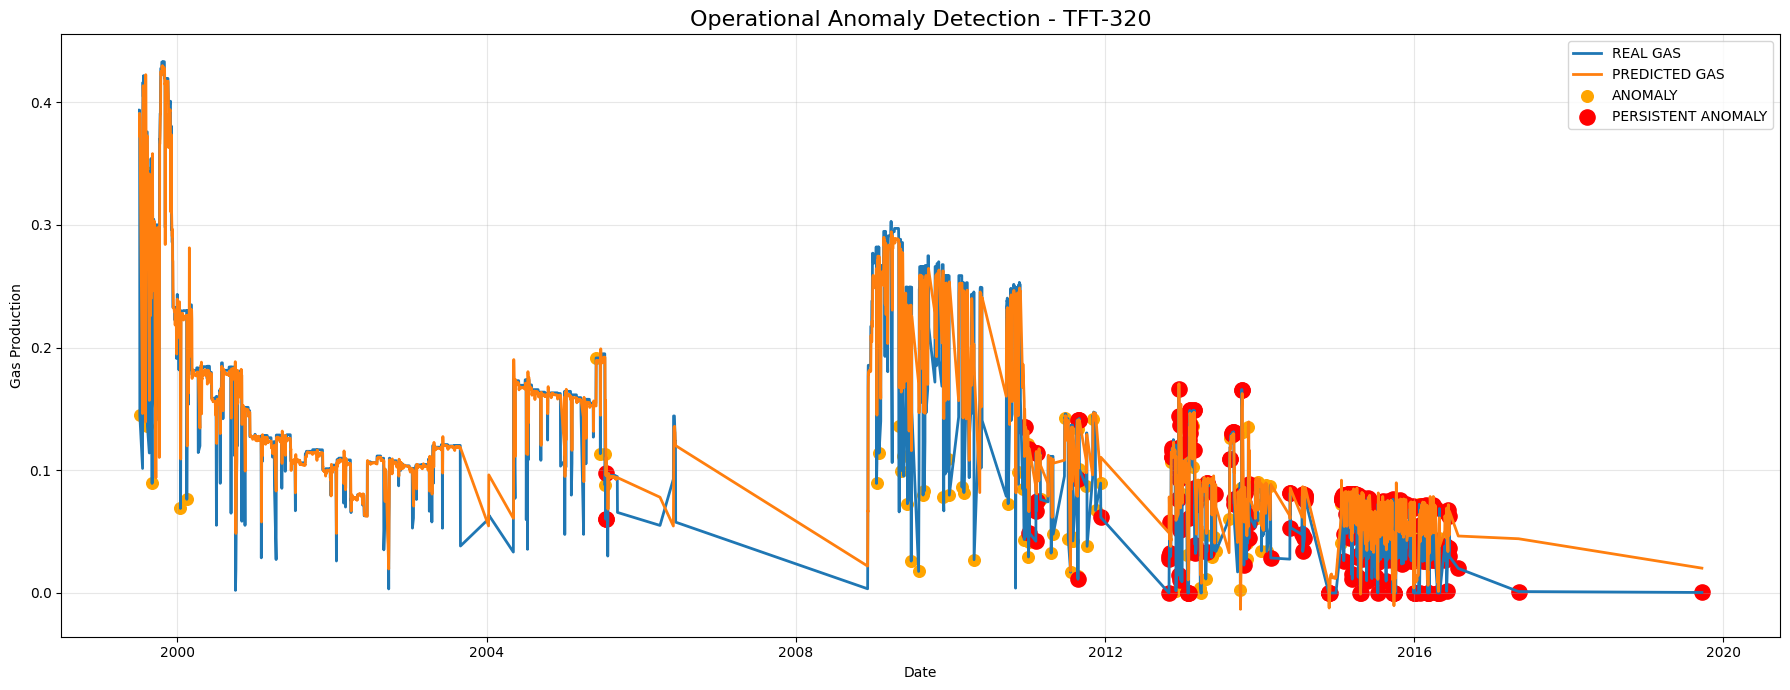

In [32]:
import matplotlib.pyplot as plt

# =========================
# WELL
# =========================

well = df_anomaly["WELL"].unique()[0]

dfp = (
    df_anomaly[df_anomaly["WELL"] == well]
    .sort_values("DATE")
)

# =========================
# ANOMALIES
# =========================

anomalies = dfp[
    dfp["IS_ANOMALY"] == 1
]

persistent = dfp[
    dfp["PERSISTENT_ANOMALY"] == 1
]

# =========================
# PLOT
# =========================

plt.figure(figsize=(18,7))

# REAL
plt.plot(
    dfp["DATE"],
    dfp["W_GAS"],
    label="REAL GAS",
    linewidth=2
)

# PRED
plt.plot(
    dfp["DATE"],
    dfp["PRED_GAS"],
    label="PREDICTED GAS",
    linewidth=2
)

# NORMAL ANOMALIES
plt.scatter(
    anomalies["DATE"],
    anomalies["W_GAS"],
    color="orange",
    s=70,
    label="ANOMALY"
)

# PERSISTENT ANOMALIES
plt.scatter(
    persistent["DATE"],
    persistent["W_GAS"],
    color="red",
    s=120,
    label="PERSISTENT ANOMALY"
)

plt.title(
    f"Operational Anomaly Detection - {well}",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("Gas Production")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [33]:
from ipywidgets import interact

wells = df_anomaly["WELL"].unique().tolist()

@interact(well=wells)

def plot_anomaly_well(well):

    dfp = (
        df_anomaly[df_anomaly["WELL"] == well]
        .sort_values("DATE")
    )

    anomalies = dfp[dfp["IS_ANOMALY"] == 1]

    persistent = dfp[dfp["PERSISTENT_ANOMALY"] == 1]

    plt.figure(figsize=(18,7))

    plt.plot(
        dfp["DATE"],
        dfp["W_GAS"],
        label="REAL"
    )

    plt.plot(
        dfp["DATE"],
        dfp["PRED_GAS"],
        label="PREDICTED"
    )

    plt.scatter(
        anomalies["DATE"],
        anomalies["W_GAS"],
        color="orange",
        s=60,
        label="ANOMALY"
    )

    plt.scatter(
        persistent["DATE"],
        persistent["W_GAS"],
        color="red",
        s=120,
        label="PERSISTENT"
    )

    plt.title(f"Gas Operational Anomalies - {well}")

    plt.legend()

    plt.grid(alpha=0.3)

    plt.show()

interactive(children=(Dropdown(description='well', options=('TFT-320', 'TFT-330', 'TFT-333Z', 'TFT-361', 'TFT-…

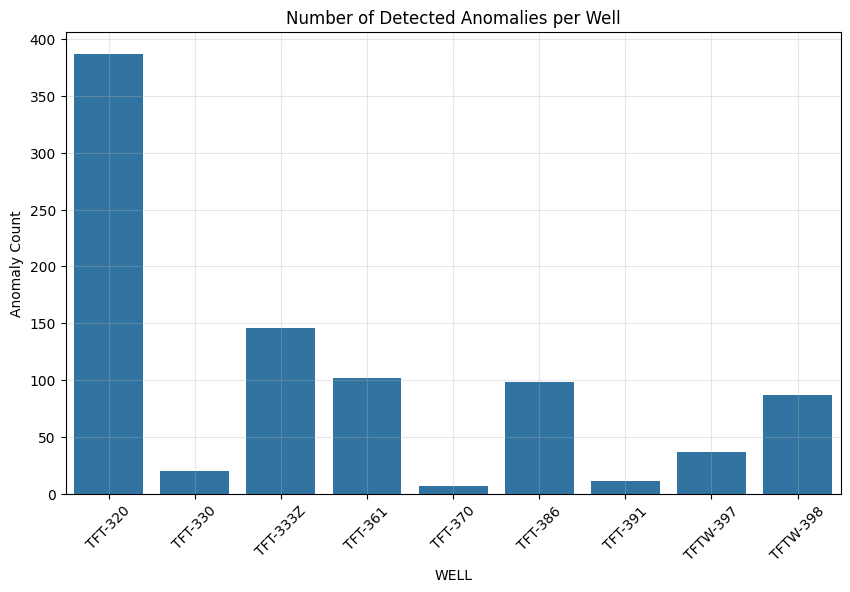

In [34]:
import seaborn as sns

heatmap_data = (
    df_anomaly
    .groupby("WELL")["IS_ANOMALY"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=heatmap_data,
    x="WELL",
    y="IS_ANOMALY"
)

plt.title("Number of Detected Anomalies per Well")

plt.ylabel("Anomaly Count")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.show()